# Modélisation et MLFlow pour le tracking d’expérimentations

### Imports essentiels

In [1]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

from codecarbon import EmissionsTracker
import time
import os

try:
    import shap
except ImportError:
    shap = None
    print("SHAP non installé, pass")


In [2]:
# Bascule vers Le GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

### Chargement des données

In [3]:

df = pd.read_csv("app_train.csv")


In [4]:
df

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_COUNT,DAYS_EMPLOYED_ANOM,TARGET
0,0,76500.0,267102.0,21415.5,247500.0,0.015221,11202,-674.0,-595.0,-3708,...,0.0,0.0,0,0,0.0,0.0,0.0,6.0,False,0
1,0,180999.0,2016000.0,57564.0,2016000.0,0.018209,20630,-659.0,-5446.0,-4163,...,NaN,NaN,2,2,NaN,NaN,NaN,NaN,False,0
2,0,54000.0,679500.0,19867.5,679500.0,0.007120,22733,NaN,-13011.0,-3854,...,NaN,NaN,2,2,NaN,NaN,NaN,NaN,False,0
3,0,225000.0,1288350.0,37800.0,1125000.0,0.072508,16821,-1020.0,-355.0,-383,...,NaN,NaN,2,2,NaN,NaN,NaN,NaN,False,0
4,2,171000.0,888840.0,29506.5,675000.0,0.004960,15511,-4974.0,-9420.0,-1566,...,NaN,NaN,2,2,NaN,NaN,NaN,NaN,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246000,0,135000.0,755190.0,30078.0,675000.0,0.019689,22141,-1830.0,-13703.0,-1053,...,0.0,0.0,0,0,0.0,0.0,0.0,83.0,False,0
246001,0,117000.0,180000.0,9000.0,180000.0,0.005144,10207,-2440.0,-1716.0,-180,...,NaN,NaN,2,2,NaN,NaN,NaN,NaN,False,0
246002,0,540000.0,724261.5,39420.0,576000.0,0.046220,11714,-549.0,-2726.0,-4378,...,0.0,0.0,0,0,0.0,0.0,0.0,23.0,False,0
246003,0,103500.0,1236816.0,40027.5,1080000.0,0.020246,18083,-3287.0,-1380.0,-1629,...,0.0,0.0,0,0,0.0,0.0,0.0,37.0,False,1


In [5]:
print(df['TARGET'].unique())

[0 1]


In [6]:
print(df['TARGET'].isna().sum())


0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246005 entries, 0 to 246004
Columns: 773 entries, CNT_CHILDREN to TARGET
dtypes: bool(140), float64(583), int64(50)
memory usage: 1.2 GB


TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


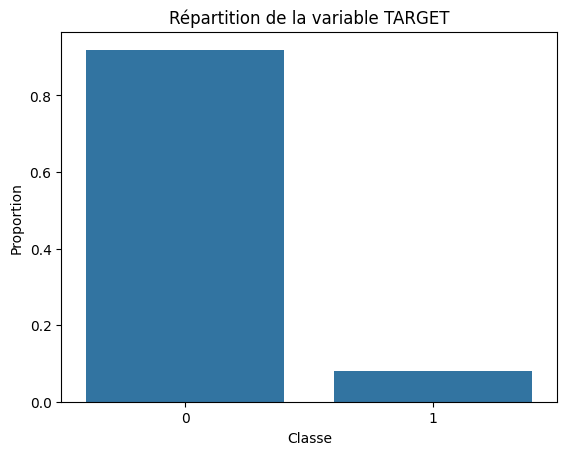

In [8]:
print(df['TARGET'].value_counts(normalize=True))


import matplotlib.pyplot as plt
import seaborn as sns

# Calcul des proportions
counts = df['TARGET'].value_counts(normalize=True)

# Graphique en barres
sns.barplot(x=counts.index, y=counts.values)
plt.xlabel('Classe')
plt.ylabel('Proportion')
plt.title('Répartition de la variable TARGET')
plt.show()


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246005 entries, 0 to 246004
Columns: 773 entries, CNT_CHILDREN to TARGET
dtypes: bool(140), float64(583), int64(50)
memory usage: 1.2 GB


### Préparation des données

Objectif : Nettoyer et préparer les données avant modélisation
 - Imputation des valeurs manquantes (par moyenne)
 - Mise à l'échelle (standardisation)

In [10]:
def prepare_data(df, target_col='TARGET'):
    y = df[target_col]
    X = df.drop(columns=[target_col])

    imputer = SimpleImputer(strategy='mean')
    X_imp = imputer.fit_transform(X)
    X_imp = pd.DataFrame(X_imp, columns=X.columns)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test, imputer, scaler

X_train, X_test, y_train, y_test, imputer, scaler = prepare_data(df)


### Business score

Objectif :
Calculer un score de performance basé sur un coût métier :
 - Les faux négatifs (FN) sont beaucoup plus coûteux que les faux positifs (FP)
 - Ici, FN est pondéré par 'weight_fn' (par défaut 10), FP par 'weight_fp' (par défaut 1) 
La formule renvoie un score normalisé entre 0 (pire) et 1 (meilleur) pour faciliter la comparaison entre modèles

In [11]:

def business_score_normalized(y_true, y_pred, weight_fn=10, weight_fp=1):
    FN = ((y_true==1)&(y_pred==0)).sum()
    FP = ((y_true==0)&(y_pred==1)).sum()
    score_raw = -(weight_fn*FN + weight_fp*FP)
    max_fn = (y_true==1).sum()
    max_fp = (y_true==0).sum()
    score_max = -(weight_fn*max_fn + weight_fp*max_fp)
    return (score_raw - score_max)/(0-score_max)


### Seuil optimal

le seuil (threshold) optimal pour transformer des probabilités en classes (0 ou 1) en maximisant le score business normalisé défini par la fonction `business_score_normalized()`.


In [12]:

def best_threshold(y_true, y_proba):
    thresholds = np.linspace(0.01,0.99,99)
    best_t, best_s = 0.5, -np.inf
    for t in thresholds:
        s = business_score_normalized(y_true, (y_proba>=t).astype(int))
        if s>best_s:
            best_s, best_t = s, t
    return best_t


### Baseline DummyClassifier

Le modèle DummyClassifier cela sert de référence simple (baseline) pour évaluer la performance minimale attendue.  


In [13]:

mlflow.set_experiment("Modele_compare_scoring")

with mlflow.start_run(run_name="Baseline_DummyClassifier"):
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train, y_train)

    y_proba = dummy.predict_proba(X_test)[:, 1]
    y_pred = dummy.predict(X_test)

    metrics = {
        'roc_auc': roc_auc_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'business_score': business_score_normalized(y_test, y_pred)
    }
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(dummy, "baseline_dummy")

    print(f"Baseline metrics: {metrics}")


2025/06/24 13:34:45 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.17.1, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
2025/06/24 13:34:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Baseline metrics: {'roc_auc': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'business_score': 0.5324253375554745}


### Fonction d'entraînement et logging MLFlow

### Fonction d'entraînement, d'optimisation et de logging dans MLflow

Cette fonction `train_and_log` automatise plusieurs étapes clés du workflow de machine learning :

- **Gestion des émissions carbone** : grâce à `EmissionsTracker`, on mesure l'impact environnemental de l'entraînement.
- **Pipeline de preprocessing et modélisation** : on crée un pipeline combinant l'imputation des valeurs manquantes, la standardisation des données, la sur-échantillonnage SMOTE pour gérer le déséquilibre, et le modèle choisi.
- **Recherche d'hyperparamètres** : un `RandomizedSearchCV` est utilisé pour optimiser les hyperparamètres selon le critère `roc_auc` en validation croisée.
- **Calcul du seuil optimal de décision** (`best_threshold`) basé sur une métrique métier personnalisée.
- **Enregistrement complet dans MLflow** : paramètres, métriques (AUC, précision, rappel, F1, score métier), temps d'entraînement, émissions carbone, et le modèle avec sa signature.
- **Retourne le meilleur modèle entraîné**.

Cette fonction facilite ainsi la comparaison, le suivi et la reproductibilité des expériences tout en intégrant des préoccupations environnementales et métier.


Nous calculons plusieurs métriques classiques :  
- **ROC AUC** : mesure la capacité du modèle à classer correctement les observations.  
- **Precision** : proportion des prédictions positives correctes.  
- **Recall** : proportion des vrais positifs détectés.  
- **F1 Score** : moyenne harmonique de la précision et du rappel.  
- **Business Score** : métrique personnalisée pénalisant plus les faux négatifs, adaptée à notre contexte métier.

Enfin, nous enregistrons ces métriques ainsi que le modèle dans MLflow pour pouvoir suivre les performances au fil des expériences.

In [14]:
def train_and_log(name, model, param_dist, X_train, y_train, X_test, y_test):
    tracker = EmissionsTracker(project_name=name)
    tracker.start()
    start_time = time.time()

    smote = SMOTE(random_state=42)
    pipeline = imPipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('smote', smote),
        ('model', model)
    ])

    rs = RandomizedSearchCV(pipeline, param_dist, cv=3, n_iter=10,
                            scoring='roc_auc', random_state=42, verbose=2)
    with mlflow.start_run(run_name=name):
        rs.fit(X_train, y_train)
        best = rs.best_estimator_

        y_proba = best.predict_proba(X_test)[:, 1]
        thresh = best_threshold(y_test, y_proba)
        y_pred = (y_proba >= thresh).astype(int)

        # Logs dans MLflow
        mlflow.log_params(rs.best_params_)
        mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_proba))
        mlflow.log_metric('precision', precision_score(y_test, y_pred, zero_division=0))
        mlflow.log_metric('recall', recall_score(y_test, y_pred))
        mlflow.log_metric('f1_score', f1_score(y_test, y_pred))
        mlflow.log_metric('business_score', business_score_normalized(y_test, y_pred))
        mlflow.log_param('best_threshold', thresh)  # seuil comme paramètre

        duration = time.time() - start_time
        emissions = tracker.stop()
        mlflow.log_metric("training_time_seconds", duration)
        mlflow.log_metric("carbon_emissions_kg", emissions)

        signature = infer_signature(X_train, best.predict(X_train))
        mlflow.sklearn.log_model(best, name + '_model', signature=signature)

        print(f"{name} entraîné et loggé dans MLflow avec params : {rs.best_params_}")

    return best


 ### Grilles pour chaque modèle

In [15]:
param_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'saga'],
    'model__penalty': ['l2', 'l1', 'elasticnet'],
    'model__l1_ratio': [None, 0.5]  # utile uniquement si penalty='elasticnet'
}


In [16]:
param_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 20, None],
    'model__class_weight': ['balanced', None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}


In [17]:
param_lgb = {
    'model__num_leaves': np.arange(20, 80, 10),
    'model__learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.3],
    'model__n_estimators': [100, 200, 300, 400],
    'model__min_child_samples': [10, 20, 30],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__class_weight': [None, 'balanced'],
    'model__max_depth': [3, 5, 10]
}


In [18]:
param_xgb = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.7, 1.0],
    'model__min_child_weight': [1, 5],
    'model__gamma': [0, 0.1]
}


### Entraînement de tous les modèles

In [20]:

best_lr = train_and_log("LogisticRegression", LogisticRegression(max_iter=1000), param_lr, X_train, y_train, X_test, y_test)

[codecarbon INFO @ 18:17:42] [setup] RAM Tracking...
[codecarbon INFO @ 18:17:42] [setup] GPU Tracking...
[codecarbon INFO @ 18:17:42] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:17:42] [setup] CPU Tracking...
[codecarbon WARNING @ 18:17:42] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:17:43] CPU Model on constant consumption mode: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 18:17:43] >>> Tracker's metadata:
[codecarbon INFO @ 18:17:43]   Platform system: Windows-11-10.0.22621-SP0
[codecarbon INFO @ 18:17:43]   Python version: 3.12.4
[codecarbon INFO @ 18:17:43]   CodeCarbon version: 2.6.0
[codecarbon INFO @ 18:17:43]   Available RAM : 31.786 GB
[codecarbon INFO @ 18:17:43]   CPU count: 12
[codecarbon INFO @ 18:17:43]   CPU model: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 18:17:43]   GPU count: 1
[codecarbon INFO @ 18:17:43]   GPU model: 1 x Quadro T1000 with Max-Q Design


ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\hardware\cpu_power.csv


[codecarbon INFO @ 18:17:44] Saving emissions data to file C:\Users\FBWG6962\Downloads\OPC\Projet_7\PROJET_7\emissions.csv


Fitting 3 folds for each of 10 candidates, totalling 30 fits


[codecarbon INFO @ 18:17:59] Energy consumed for RAM : 0.000050 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 18:17:59] Energy consumed for all GPUs : 0.000013 kWh. Total GPU Power : 3.0700198404241394 W
[codecarbon INFO @ 18:17:59] Energy consumed for all CPUs : 0.000094 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 18:17:59] 0.000156 kWh of electricity used since the beginning.
[codecarbon INFO @ 18:18:14] Energy consumed for RAM : 0.000099 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 18:18:14] Energy consumed for all GPUs : 0.000026 kWh. Total GPU Power : 3.1990125401192824 W
[codecarbon INFO @ 18:18:14] Energy consumed for all CPUs : 0.000188 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 18:18:14] 0.000313 kWh of electricity used since the beginning.


...

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


[codecarbon INFO @ 04:18:19] Energy consumed for RAM : 0.114842 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 04:18:20] Energy consumed for all GPUs : -0.008353 kWh. Total GPU Power : 6.916434549579426e-05 W
[codecarbon INFO @ 04:18:20] Energy consumed for all CPUs : 0.225194 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 04:18:20] 0.331683 kWh of electricity used since the beginning.
[codecarbon INFO @ 04:18:34] Energy consumed for RAM : 0.114890 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 04:18:35] Energy consumed for all GPUs : -0.008353 kWh. Total GPU Power : 0.0016603451290242537 W
[codecarbon INFO @ 04:18:35] Energy consumed for all CPUs : 0.225287 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 04:18:35] 0.331824 kWh of electricity used since the beginning.
[codecarbon INFO @ 04:18:49] Energy consumed for RAM : 0.114938 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 04:18:50] Energy consumed for all GPUs : -0.008353 kWh. Total GPU Power : 0.0

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


2025/06/18 04:21:04 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.17.1, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


LogisticRegression entraîné et loggé dans MLflow avec params : {'model__solver': 'saga', 'model__penalty': 'l1', 'model__l1_ratio': 0.5, 'model__C': 0.1}


In [21]:

best_rf = train_and_log("RandomForest", RandomForestClassifier(random_state=42), param_rf, X_train, y_train, X_test, y_test)

[codecarbon INFO @ 04:21:04] [setup] RAM Tracking...
[codecarbon INFO @ 04:21:04] [setup] GPU Tracking...
[codecarbon INFO @ 04:21:04] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 04:21:05] [setup] CPU Tracking...
[codecarbon WARNING @ 04:21:05] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 04:21:07] CPU Model on constant consumption mode: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 04:21:07] >>> Tracker's metadata:
[codecarbon INFO @ 04:21:07]   Platform system: Windows-11-10.0.22621-SP0
[codecarbon INFO @ 04:21:07]   Python version: 3.12.4
[codecarbon INFO @ 04:21:07]   CodeCarbon version: 2.6.0
[codecarbon INFO @ 04:21:07]   Available RAM : 31.786 GB
[codecarbon INFO @ 04:21:07]   CPU count: 12
[codecarbon INFO @ 04:21:07]   CPU model: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 04:21:07]   GPU count: 1
[codecarbon INFO @ 04:21:07]   GPU model: 1 x Quadro T1000 with Max-Q Design


ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\hardware\cpu_power.csv


[codecarbon INFO @ 04:21:07] Saving emissions data to file C:\Users\FBWG6962\Downloads\OPC\Projet_7\PROJET_7\emissions.csv


Fitting 3 folds for each of 10 candidates, totalling 30 fits


[codecarbon INFO @ 04:21:22] Energy consumed for RAM : 0.000050 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 04:21:23] Energy consumed for all GPUs : -0.000002 kWh. Total GPU Power : 0.3634261023509005 W
[codecarbon INFO @ 04:21:23] Energy consumed for all CPUs : 0.000099 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 04:21:23] 0.000148 kWh of electricity used since the beginning.
[codecarbon INFO @ 04:21:37] Energy consumed for RAM : 0.000096 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 04:21:38] Energy consumed for all GPUs : -0.000002 kWh. Total GPU Power : 0.0025475090455247323 W
[codecarbon INFO @ 04:21:38] Energy consumed for all CPUs : 0.000191 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 04:21:38] 0.000286 kWh of electricity used since the beginning.
[codecarbon INFO @ 04:21:52] Energy consumed for RAM : 0.000144 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 04:21:53] Energy consumed for all GPUs : -0.000002 kWh. Total GPU Power : 0.0029

...

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


[codecarbon INFO @ 08:01:30] Energy consumed for RAM : 0.042123 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 08:01:31] Energy consumed for all GPUs : -0.000002 kWh. Total GPU Power : 0.0006921510815374504 W
[codecarbon INFO @ 08:01:31] Energy consumed for all CPUs : 0.082638 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 08:01:31] 0.124759 kWh of electricity used since the beginning.
[codecarbon INFO @ 08:01:32] Energy consumed for RAM : 0.042127 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 08:01:32] Energy consumed for all GPUs : -0.000000 kWh. Total GPU Power : 3.4604280600688853 W
[codecarbon INFO @ 08:01:32] Energy consumed for all CPUs : 0.082645 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 08:01:32] 0.124771 kWh of electricity used since the beginning.


ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


2025/06/18 08:04:01 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.17.1, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


RandomForest entraîné et loggé dans MLflow avec params : {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 20, 'model__class_weight': None}


In [19]:

best_lgb= train_and_log("LightGBM", LGBMClassifier(random_state=42), param_lgb, X_train, y_train, X_test, y_test)

[codecarbon INFO @ 13:34:45] [setup] RAM Tracking...
[codecarbon INFO @ 13:34:45] [setup] GPU Tracking...
[codecarbon INFO @ 13:34:45] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 13:34:45] [setup] CPU Tracking...
[codecarbon WARNING @ 13:34:45] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 13:34:47] CPU Model on constant consumption mode: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 13:34:47] >>> Tracker's metadata:
[codecarbon INFO @ 13:34:47]   Platform system: Windows-11-10.0.22621-SP0
[codecarbon INFO @ 13:34:47]   Python version: 3.12.4
[codecarbon INFO @ 13:34:47]   CodeCarbon version: 2.6.0
[codecarbon INFO @ 13:34:47]   Available RAM : 31.786 GB
[codecarbon INFO @ 13:34:47]   CPU count: 12
[codecarbon INFO @ 13:34:47]   CPU model: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 13:34:47]   GPU count: 1
[codecarbon INFO @ 13:34:47]   GPU model: 1 x Quadro T1000 with Max-Q Design


ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\hardware\cpu_power.csv


[codecarbon INFO @ 13:34:47] Saving emissions data to file C:\Users\FBWG6962\Downloads\OPC\Projet_7\PROJET_7\emissions.csv


Fitting 3 folds for each of 10 candidates, totalling 30 fits


[codecarbon INFO @ 13:35:02] Energy consumed for RAM : 0.000050 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 13:35:02] Energy consumed for all GPUs : 0.000013 kWh. Total GPU Power : 3.1529866789414287 W
[codecarbon INFO @ 13:35:02] Energy consumed for all CPUs : 0.000094 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 13:35:02] 0.000157 kWh of electricity used since the beginning.


...

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


[codecarbon INFO @ 14:07:04] Energy consumed for RAM : 0.006399 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 14:07:04] Energy consumed for all GPUs : 0.001755 kWh. Total GPU Power : 3.2889869913631644 W
[codecarbon INFO @ 14:07:04] Energy consumed for all CPUs : 0.012101 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 14:07:04] 0.020254 kWh of electricity used since the beginning.
[codecarbon INFO @ 14:07:19] Energy consumed for RAM : 0.006449 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 14:07:19] Energy consumed for all GPUs : 0.001768 kWh. Total GPU Power : 3.2844975400260648 W
[codecarbon INFO @ 14:07:19] Energy consumed for all CPUs : 0.012194 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 14:07:19] 0.020411 kWh of electricity used since the beginning.
[codecarbon INFO @ 14:07:34] Energy consumed for RAM : 0.006498 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 14:07:34] Energy consumed for all GPUs : 0.001782 kWh. Total GPU Power : 3.2643426210

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


2025/06/24 14:09:50 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.17.1, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


LightGBM entraîné et loggé dans MLflow avec params : {'model__subsample': 0.8, 'model__num_leaves': 50, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__class_weight': 'balanced'}


In [14]:
best_xgb = train_and_log(
    "XGBoost_GPU",
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=1
    ),
    param_xgb,
    X_train, 
    y_train, 
    X_test, 
    y_test
)

[codecarbon INFO @ 09:22:18] [setup] RAM Tracking...
[codecarbon INFO @ 09:22:18] [setup] GPU Tracking...
[codecarbon INFO @ 09:22:19] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 09:22:19] [setup] CPU Tracking...
[codecarbon WARNING @ 09:22:19] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 09:22:21] CPU Model on constant consumption mode: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 09:22:21] >>> Tracker's metadata:
[codecarbon INFO @ 09:22:21]   Platform system: Windows-11-10.0.22621-SP0
[codecarbon INFO @ 09:22:21]   Python version: 3.12.4
[codecarbon INFO @ 09:22:21]   CodeCarbon version: 2.6.0
[codecarbon INFO @ 09:22:21]   Available RAM : 31.786 GB
[codecarbon INFO @ 09:22:21]   CPU count: 12
[codecarbon INFO @ 09:22:21]   CPU model: Intel(R) Core(TM) i7-10850H CPU @ 2.70GHz
[codecarbon INFO @ 09:22:21]   GPU count: 1
[codecarbon INFO @ 09:22:21]   GPU model: 1 x Quadro T1000 with Max-Q Design


ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\hardware\cpu_power.csv


[codecarbon INFO @ 09:22:21] Saving emissions data to file C:\Users\FBWG6962\Downloads\OPC\Projet_7\PROJET_7\emissions.csv


Fitting 3 folds for each of 10 candidates, totalling 30 fits


[codecarbon INFO @ 09:22:36] Energy consumed for RAM : 0.000050 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 09:22:36] Energy consumed for all GPUs : 0.000004 kWh. Total GPU Power : 0.9078037745454546 W
[codecarbon INFO @ 09:22:36] Energy consumed for all CPUs : 0.000094 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 09:22:36] 0.000147 kWh of electricity used since the beginning.
[codecarbon INFO @ 09:22:51] Energy consumed for RAM : 0.000099 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 09:22:51] Energy consumed for all GPUs : 0.000003 kWh. Total GPU Power : 0.18437565259983055 W
[codecarbon INFO @ 09:22:51] Energy consumed for all CPUs : 0.000188 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 09:22:51] 0.000290 kWh of electricity used since the beginning.
[codecarbon INFO @ 09:23:06] Energy consumed for RAM : 0.000149 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 09:23:06] Energy consumed for all GPUs : 0.000006 kWh. Total GPU Power : 0.607047404

...

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


[codecarbon INFO @ 11:08:40] Energy consumed for RAM : 0.021069 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 11:08:40] Energy consumed for all GPUs : 0.002464 kWh. Total GPU Power : 2.9249615162461136 W
[codecarbon INFO @ 11:08:40] Energy consumed for all CPUs : 0.039860 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 11:08:40] 0.063394 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:08:55] Energy consumed for RAM : 0.021119 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 11:08:55] Energy consumed for all GPUs : 0.002476 kWh. Total GPU Power : 2.9168237744571703 W
[codecarbon INFO @ 11:08:55] Energy consumed for all CPUs : 0.039954 kWh. Total CPU Power : 22.5 W
[codecarbon INFO @ 11:08:55] 0.063549 kWh of electricity used since the beginning.
[codecarbon INFO @ 11:09:10] Energy consumed for RAM : 0.021168 kWh. RAM Power : 11.919673919677736 W
[codecarbon INFO @ 11:09:10] Energy consumed for all GPUs : 0.002488 kWh. Total GPU Power : 2.8986168491

ref: C:\Users\FBWG6962\AppData\Local\Programs\Python\Python312\Lib\site-packages\codecarbon\data\private_infra\global_energy_mix.json


2025/06/18 11:12:00 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 2.17.1, required: mlflow==2.21.3)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


XGBoost_GPU entraîné et loggé dans MLflow avec params : {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.7}


In [17]:
import mlflow

run_id = "33c45f43cb1840dc974b273bca0928f2"
artifact_path = "LightGBM_model"  # le nom que tu as utilisé dans `log_model(...)`
model_uri = f"runs:/{run_id}/{artifact_path}"

# 🔁 Enregistrement dans le model registry
registered_model_name = "LightGBM_pipeline_model"
mlflow.register_model(model_uri, registered_model_name)


Registered model 'LightGBM_pipeline_model' already exists. Creating a new version of this model...
Created version '4' of model 'LightGBM_pipeline_model'.


<ModelVersion: aliases=[], creation_timestamp=1750239623873, current_stage='None', description=None, last_updated_timestamp=1750239623873, name='LightGBM_pipeline_model', run_id='33c45f43cb1840dc974b273bca0928f2', run_link=None, source='file:///C:/Users/FBWG6962/Downloads/OPC/Projet_7/PROJET_7/mlruns/339738768820109434/33c45f43cb1840dc974b273bca0928f2/artifacts/LightGBM_model', status='READY', status_message=None, tags={}, user_id=None, version=4>

### Sauvegarde locale du meilleur modèle

In [ ]:
import joblib
joblib.dump(best_lgbm, 'best_lgb_pipeline.pkl')
print("Pipeline LightGBM saved.")


## Shap

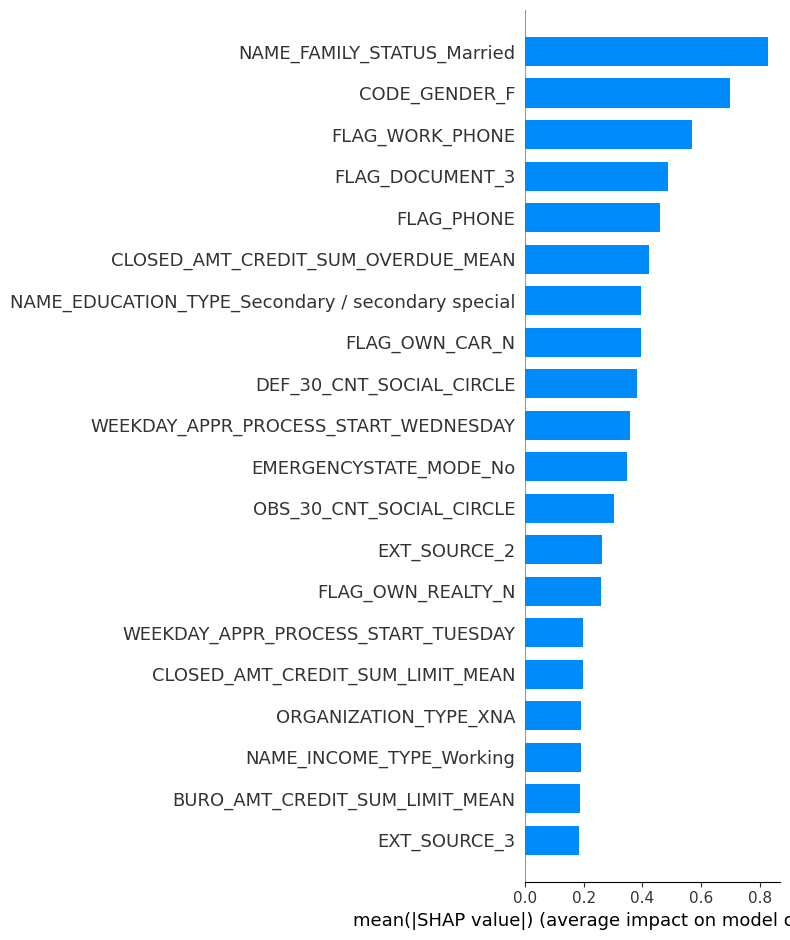

In [21]:
import shap

# Expliquer le modèle
explainer = shap.TreeExplainer(best_lgb.named_steps['model'])
shap_values = explainer.shap_values(X_test)

# Graphique global des features importance
shap.summary_plot(shap_values, X_test, plot_type="bar")


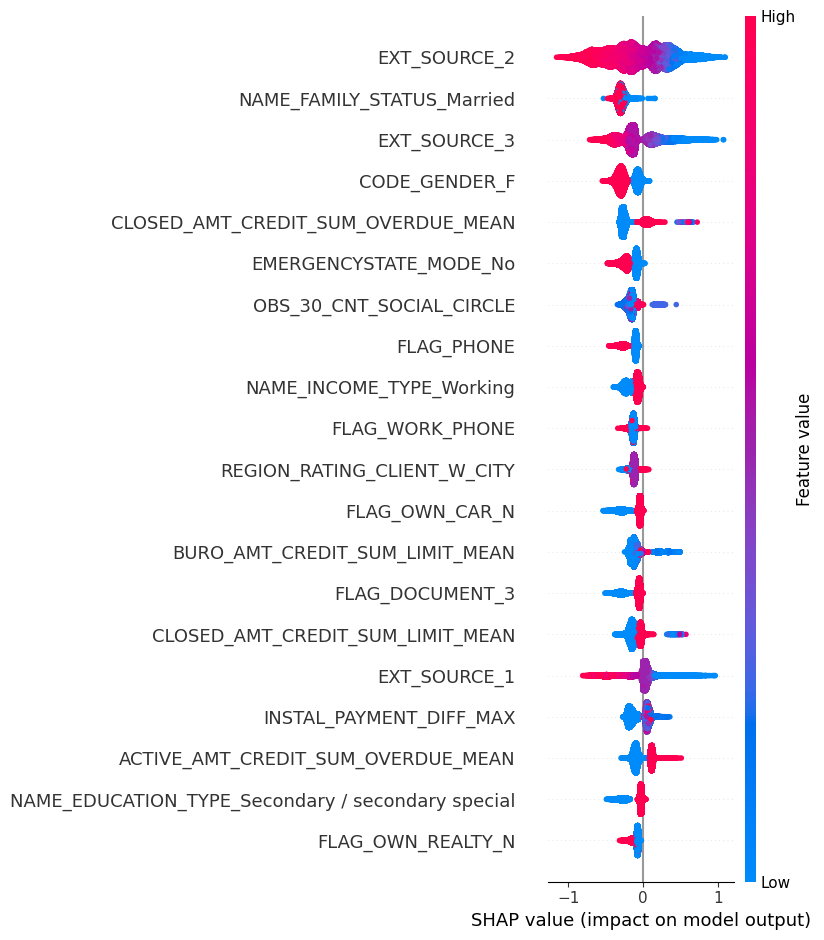

In [23]:
# 🔍 Cellule 7 : SHAP Global (pour arbre)
def shap_global(model, X_tr):
    if shap is None:
        return
    expl = shap.TreeExplainer(model.named_steps['model'])
    X_imp = model.named_steps['scaler'].transform(
        model.named_steps['imputer'].transform(X_tr)
    )
    vals = expl.shap_values(X_imp)
    shap.summary_plot(vals, X_imp, feature_names=X_tr.columns)

shap_global(best_lgb, X_train)

Ce graphique montre quelles variables influencent le plus les prédictions du modèle. Plus une variable est en haut, plus elle a d’impact. Les couleurs nous montrent si des valeurs hautes ou basses de cette variable augmentent ou diminuent le risque de défaut. Cela aide à interpréter le fonctionnement interne du modèle

<Figure size 640x480 with 0 Axes>

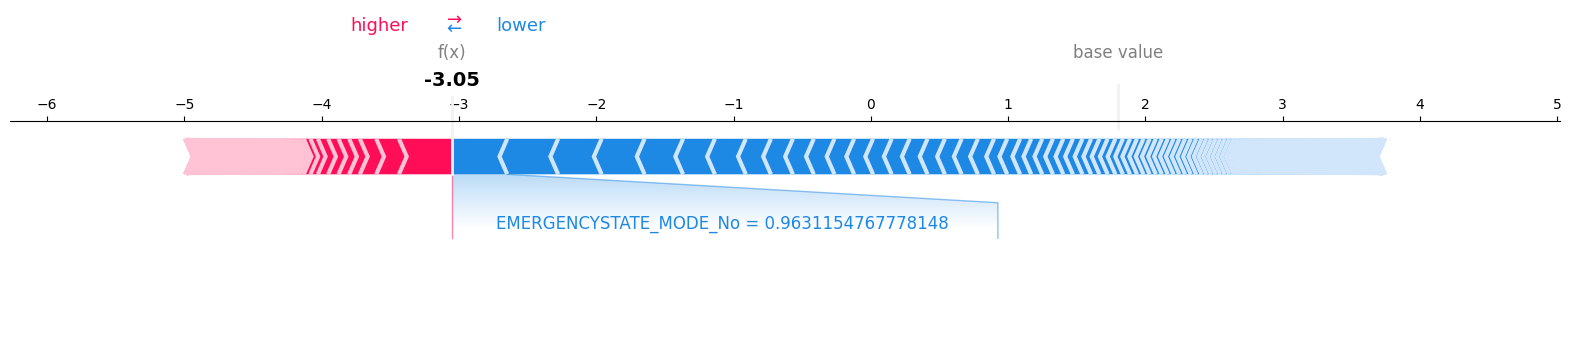

<Figure size 640x480 with 0 Axes>

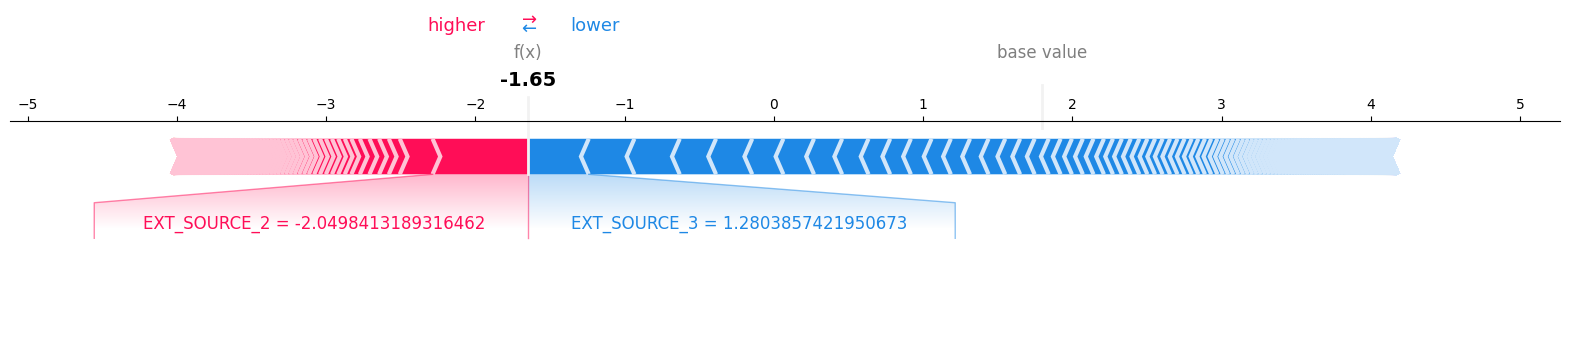

<Figure size 640x480 with 0 Axes>

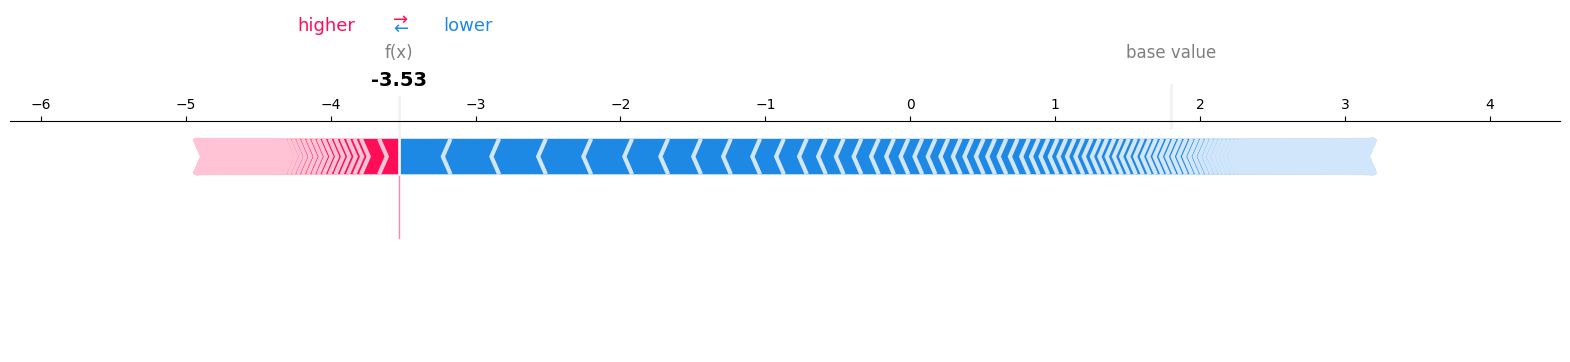

In [24]:
def shap_local(model, X_tr, model_name="model", nb_instances=5):
    """
    Génère des graphiques SHAP locaux (force plot) pour quelques prédictions.
    """
    explainer = shap.TreeExplainer(model.named_steps['model'])
    X_imp = model.named_steps['scaler'].transform(
        model.named_steps['imputer'].transform(X_tr)
    )
    shap_values = explainer.shap_values(X_imp)

    for i in range(nb_instances):
        plt.figure()
        shap.force_plot(
            explainer.expected_value,
            shap_values[i],
            X_tr.iloc[i, :],
            matplotlib=True,
            show=False
        )
shap_local(best_lgb, X_train, model_name="lgbm", nb_instances=3)